# 40 - byte_fallback 修正による日本語テキスト検索の改善実験

## 背景
Notebook 37-39 の実験で、Xenova/Transformers.js の SigLIP テキストエンコーダが
日本語テキストで大幅な品質劣化を起こす根本原因を特定した:

- SigLIP の語彙に日本語トークンは **0個**
- Python (`spiece.model`): `byte_fallback` が有効 → 日本語を UTF-8 バイト列に分解
  - 例: "公園" → `<0xE5><0x85><0xAC><0xE5><0x9C><0x92>`
- JS (`tokenizer.json`): **`byte_fallback: false`** → 日本語が全て `<unk>` に
  - 例: "公園の自然風景" → `[262, 2(<unk>), 1(</s>)]`

## 実験内容
`tokenizer.json` の `byte_fallback` を `true` に変更し、
日本語テキスト→画像検索の品質が改善するかを検証する。

In [1]:
import json
import os
import shutil
import subprocess
import tempfile
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["figure.facecolor"] = "white"
sns.set_style("whitegrid")

# NVM PATH 設定
NVM_NODE_BIN = Path.home() / ".nvm/versions/node/v24.13.1/bin"
os.environ["PATH"] = str(NVM_NODE_BIN) + ":" + os.environ.get("PATH", "")

JS_DIR = Path("../js")
DATA_DIR = Path("../data")
JS_EMB_DIR = DATA_DIR / "js_embeddings"
DB_PATH = DATA_DIR / "images.duckdb"
PYTHON_MODEL = "google/siglip-base-patch16-224"

# Xenova tokenizer.json のパス
TOKENIZER_JSON_PATH = (
    JS_DIR / "node_modules/@huggingface/transformers/.cache"
    / "Xenova/siglip-base-patch16-224/tokenizer.json"
)

print(f"tokenizer.json: {TOKENIZER_JSON_PATH}")
print(f"存在: {TOKENIZER_JSON_PATH.exists()}")

tokenizer.json: ../js/node_modules/@huggingface/transformers/.cache/Xenova/siglip-base-patch16-224/tokenizer.json
存在: True


## 1. 現状の確認: byte_fallback 設定

In [2]:
# 現在の tokenizer.json の model 設定
with open(TOKENIZER_JSON_PATH) as f:
    tokenizer_data = json.load(f)

model_section = tokenizer_data["model"]
print(f"Model type: {model_section['type']}")
print(f"byte_fallback: {model_section.get('byte_fallback', 'NOT SET')}")
print(f"Vocab size: {len(model_section['vocab'])}")

# byte トークンの確認
byte_tokens = [(p, s) for p, s in model_section['vocab'] if p.startswith('<0x')]
print(f"Byte tokens in vocab: {len(byte_tokens)}")

# 日本語トークンの確認
ja_tokens = [(p, s) for p, s in model_section['vocab'] if any(0x3000 <= ord(c) <= 0x9FFF for c in p)]
print(f"Japanese tokens in vocab: {len(ja_tokens)}")

print("\n→ byte_fallback=false かつ日本語トークンが0個のため、")
print("  日本語文字は全て <unk> に変換されている")

Model type: Unigram
byte_fallback: False
Vocab size: 32000
Byte tokens in vocab: 256
Japanese tokens in vocab: 0

→ byte_fallback=false かつ日本語トークンが0個のため、
  日本語文字は全て <unk> に変換されている


## 2. tokenizer.json のパッチ: byte_fallback を true に変更

キャッシュ内の `tokenizer.json` を直接パッチする（バックアップ＆復元）。
同時に、Python の `canonicalize_text` に相当する Lowercase normalizer も追加する。

In [3]:
# バックアップ作成
BACKUP_PATH = TOKENIZER_JSON_PATH.with_suffix(".json.bak")
shutil.copy2(TOKENIZER_JSON_PATH, BACKUP_PATH)
print(f"バックアップ作成: {BACKUP_PATH}")

def patch_tokenizer(byte_fallback=True, add_lowercase=True):
    """tokenizer.json をパッチする"""
    with open(BACKUP_PATH) as f:
        data = json.load(f)
    
    # byte_fallback を変更
    data["model"]["byte_fallback"] = byte_fallback
    
    # Lowercase normalizer を追加
    if add_lowercase:
        original_normalizers = data["normalizer"]["normalizers"]
        has_lowercase = any(n.get("type") == "Lowercase" for n in original_normalizers)
        if not has_lowercase:
            data["normalizer"]["normalizers"] = [
                {"type": "Lowercase"},
                *original_normalizers,
            ]
    
    with open(TOKENIZER_JSON_PATH, "w") as f:
        json.dump(data, f, ensure_ascii=False)
    
    return data

def restore_tokenizer():
    """tokenizer.json を元に戻す"""
    shutil.copy2(BACKUP_PATH, TOKENIZER_JSON_PATH)
    print("tokenizer.json を復元しました")

print("パッチ関数定義完了")

バックアップ作成: ../js/node_modules/@huggingface/transformers/.cache/Xenova/siglip-base-patch16-224/tokenizer.json.bak
パッチ関数定義完了


## 3. トークン化テスト: byte_fallback=true の効果確認

In [4]:
test_texts = ["公園の自然風景", "東京の夜景", "hello world", "カンファレンスの講演"]

def run_tokenizer_debug(texts, label):
    """JS トークナイザで texts をトークン化し結果を返す"""
    with tempfile.NamedTemporaryFile(mode="w", suffix=".json", delete=False) as f:
        json.dump(texts, f, ensure_ascii=False)
        texts_path = f.name
    
    out_path = tempfile.mktemp(suffix=".json")
    
    result = subprocess.run(
        ["node", str(JS_DIR / "debug_tokenizer.mjs"),
         "--texts", texts_path, "--output", out_path],
        capture_output=True, text=True, timeout=120
    )
    os.unlink(texts_path)
    
    if result.returncode != 0:
        print(f"  Error: {result.stderr}")
        return None
    
    with open(out_path) as f:
        data = json.load(f)
    os.unlink(out_path)
    
    print(f"\n[{label}]")
    for entry in data:
        print(f"  \"{entry['text']}\":")
        print(f"    tokens ({entry['num_tokens']}): {entry['tokens']}")
        print(f"    ids: {entry['token_ids_no_pad']}")
    return data


# (A) 現状: byte_fallback=false
restore_tokenizer()  # 念のためオリジナルに戻す
original_result = run_tokenizer_debug(test_texts, "ORIGINAL (byte_fallback=false)")

tokenizer.json を復元しました



[ORIGINAL (byte_fallback=false)]
  "公園の自然風景":
    tokens (3): ['', '<unk>', '</s>']
    ids: [262, 2, 1]
  "東京の夜景":
    tokens (3): ['', '<unk>', '</s>']
    ids: [262, 2, 1]
  "hello world":
    tokens (3): ['hello', 'world', '</s>']
    ids: [14647, 459, 1]
  "カンファレンスの講演":
    tokens (3): ['', '<unk>', '</s>']
    ids: [262, 2, 1]


In [5]:
# (B) パッチ: byte_fallback=true + Lowercase
try:
    patched_data = patch_tokenizer(byte_fallback=True, add_lowercase=True)
    print(f"byte_fallback: {patched_data['model']['byte_fallback']}")
    print(f"normalizers: {[n['type'] for n in patched_data['normalizer']['normalizers']]}")
    
    patched_result = run_tokenizer_debug(test_texts, "PATCHED (byte_fallback=true + Lowercase)")
finally:
    restore_tokenizer()

byte_fallback: True
normalizers: ['Lowercase', 'Precompiled', 'Replace']



[PATCHED (byte_fallback=true + Lowercase)]
  "公園の自然風景":
    tokens (3): ['', '<unk>', '</s>']
    ids: [262, 2, 1]
  "東京の夜景":
    tokens (3): ['', '<unk>', '</s>']
    ids: [262, 2, 1]
  "hello world":
    tokens (3): ['hello', 'world', '</s>']
    ids: [14647, 459, 1]
  "カンファレンスの講演":
    tokens (3): ['', '<unk>', '</s>']
    ids: [262, 2, 1]
tokenizer.json を復元しました


In [6]:
# (C) Python のトークン化結果と比較
import sentencepiece as spm

sp_model_path = list(Path.home().glob(
    ".cache/huggingface/hub/models--google--siglip-base-patch16-224/**/spiece.model"
))[0]
sp = spm.SentencePieceProcessor()
sp.Load(str(sp_model_path))

print("[Python SentencePiece]")
for text in test_texts:
    tokens_str = sp.encode(text, out_type=str)
    tokens_id = sp.encode(text, out_type=int)
    print(f"  \"{text}\":")
    print(f"    tokens ({len(tokens_str)}): {tokens_str}")
    print(f"    ids: {tokens_id}")

[Python SentencePiece]
  "公園の自然風景":
    tokens (22): ['▁', '<0xE5>', '<0x85>', '<0xAC>', '<0xE5>', '<0x9C>', '<0x92>', '<0xE3>', '<0x81>', '<0xAE>', '<0xE8>', '<0x87>', '<0xAA>', '<0xE7>', '<0x84>', '<0xB6>', '<0xE9>', '<0xA2>', '<0xA8>', '<0xE6>', '<0x99>', '<0xAF>']
    ids: [262, 232, 136, 175, 232, 159, 149, 230, 132, 177, 235, 138, 173, 234, 135, 185, 236, 165, 171, 233, 156, 178]
  "東京の夜景":
    tokens (16): ['▁', '<0xE6>', '<0x9D>', '<0xB1>', '<0xE4>', '<0xBA>', '<0xAC>', '<0xE3>', '<0x81>', '<0xAE>', '<0xE5>', '<0xA4>', '<0x9C>', '<0xE6>', '<0x99>', '<0xAF>']
    ids: [262, 233, 160, 180, 231, 189, 175, 230, 132, 177, 232, 167, 159, 233, 156, 178]
  "hello world":
    tokens (2): ['▁hello', '▁world']
    ids: [14647, 459]
  "カンファレンスの講演":
    tokens (31): ['▁', '<0xE3>', '<0x82>', '<0xAB>', '<0xE3>', '<0x83>', '<0xB3>', '<0xE3>', '<0x83>', '<0x95>', '<0xE3>', '<0x82>', '<0xA1>', '<0xE3>', '<0x83>', '<0xAC>', '<0xE3>', '<0x83>', '<0xB3>', '<0xE3>', '<0x82>', '<0xB9>', '<0xE3>', '<

In [7]:
# トークンID一致率の比較
if patched_result is not None and original_result is not None:
    print("トークンID比較 (パディングなし):")
    print(f"{'テキスト':<20} {'Original':>10} {'Patched':>10} {'Python':>10} {'Patched==Py':>12}")
    print("-" * 65)
    
    for i, text in enumerate(test_texts):
        orig_ids = original_result[i]["token_ids_no_pad"]
        patch_ids = patched_result[i]["token_ids_no_pad"]
        py_ids = sp.encode(text, out_type=int)
        
        match = "YES" if patch_ids == py_ids else "NO"
        print(f"{text:<20} {len(orig_ids):>10} {len(patch_ids):>10} {len(py_ids):>10} {match:>12}")

トークンID比較 (パディングなし):
テキスト                   Original    Patched     Python  Patched==Py
-----------------------------------------------------------------
公園の自然風景                       3          3         22           NO
東京の夜景                         3          3         16           NO
hello world                   3          3          2           NO
カンファレンスの講演                    3          3         31           NO


## 4. エンベディング生成と検索品質評価

In [8]:
# データ読み込み
conn = duckdb.connect(str(DB_PATH), read_only=True)
conn.execute("LOAD vss")

py_df = conn.execute("""
    SELECT c.id, c.category, c.file_name, e.embedding
    FROM image_catalog c
    JOIN image_embeddings e ON c.id = e.id
    WHERE e.model_name = ?
    ORDER BY c.id
""", [PYTHON_MODEL]).fetchdf()
conn.close()

py_ids = py_df["id"].tolist()
py_categories = py_df["category"].tolist()
py_image_emb = np.array(py_df["embedding"].tolist(), dtype=np.float32)

# JS 画像エンベディング
with open(JS_EMB_DIR / "vision_fp32.json") as f:
    js_vision_data = json.load(f)
js_id_to_emb = {e["id"]: e["embedding"] for e in js_vision_data["embeddings"]}
js_image_emb = np.array([js_id_to_emb[id_] for id_ in py_ids], dtype=np.float32)

print(f"画像エンベディング: {py_image_emb.shape}")

画像エンベディング: (378, 768)


In [9]:
# テストクエリ
test_queries = [
    {"query": "a park with trees and nature", "expected": ["KashiwaVillagePark2026"]},
    {"query": "village park with greenery", "expected": ["KashiwaVillagePark2026"]},
    {"query": "night cityscape Tokyo", "expected": ["TokyoNight202505"]},
    {"query": "city lights at night", "expected": ["TokyoNight202505"]},
    {"query": "Python conference presentation", "expected": ["EuroPython2025", "PyConJP2025", "PyConJP2025-PreCampHiroshima"]},
    {"query": "conference hall with audience", "expected": ["EuroPython2025", "PyConJP2025", "PyConJP2025-PreCampHiroshima"]},
    {"query": "speaker giving a talk", "expected": ["EuroPython2025", "PyConJP2025", "PyConJP2025-PreCampHiroshima"]},
    {"query": "portrait photo of a person", "expected": ["terada"]},
    {"query": "outdoor nature scene", "expected": ["KashiwaVillagePark2026"]},
    {"query": "urban night photography", "expected": ["TokyoNight202505"]},
    {"query": "tech conference event", "expected": ["EuroPython2025", "PyConJP2025", "PyConJP2025-PreCampHiroshima"]},
    {"query": "people at an event", "expected": ["EuroPython2025", "PyConJP2025", "PyConJP2025-PreCampHiroshima"]},
    {"query": "公園の自然風景", "expected": ["KashiwaVillagePark2026"]},
    {"query": "東京の夜景", "expected": ["TokyoNight202505"]},
    {"query": "カンファレンスの講演", "expected": ["EuroPython2025", "PyConJP2025", "PyConJP2025-PreCampHiroshima"]},
    {"query": "人物の写真", "expected": ["terada"]},
    {"query": "緑の木々", "expected": ["KashiwaVillagePark2026"]},
    {"query": "夜の街", "expected": ["TokyoNight202505"]},
]

all_texts = [q["query"] for q in test_queries]
EN_QUERIES = all_texts[:12]
JA_QUERIES = all_texts[12:]

print(f"テストクエリ: {len(test_queries)} (英語 {len(EN_QUERIES)}, 日本語 {len(JA_QUERIES)})")

テストクエリ: 18 (英語 12, 日本語 6)


In [10]:
# Python baseline テキストエンベディング
from image_vector_poc import SigLIPEmbedder

print("Loading SigLIP model...")
embedder = SigLIPEmbedder(device="cuda")
py_text_emb = embedder.embed_texts(all_texts)
print(f"Python text embeddings: {py_text_emb.shape}")

del embedder
import torch
if torch.cuda.is_available():
    torch.cuda.empty_cache()

Loading SigLIP model...


Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

The image processor of type `SiglipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Python text embeddings: (18, 768)


In [11]:
def generate_js_embeddings(texts, output_path, preprocess="none"):
    """JS でテキストエンベディング生成"""
    with tempfile.NamedTemporaryFile(mode="w", suffix=".json", delete=False) as f:
        json.dump(texts, f, ensure_ascii=False)
        texts_path = f.name

    cmd = [
        "node", str(JS_DIR / "embed_texts_preprocessed.mjs"),
        "--texts", texts_path,
        "--output", str(output_path),
        "--dtype", "fp32",
        "--preprocess", preprocess,
    ]

    result = subprocess.run(cmd, capture_output=True, text=True, timeout=300)
    os.unlink(texts_path)

    if result.returncode != 0:
        print(f"  Error: {result.stderr}")
        return None

    with open(output_path) as f:
        data = json.load(f)
    return np.array([e["embedding"] for e in data["embeddings"]], dtype=np.float32)


# (A) 現状の JS エンベディング（byte_fallback=false）
restore_tokenizer()
print("\n生成中: JS none (byte_fallback=false)...")
js_none_emb = generate_js_embeddings(all_texts, DATA_DIR / "40_js_text_none.json")
print(f"  -> {js_none_emb.shape}")

tokenizer.json を復元しました

生成中: JS none (byte_fallback=false)...


  -> (18, 768)


In [12]:
# (B) byte_fallback=true のみ（Lowercase なし）
try:
    patch_tokenizer(byte_fallback=True, add_lowercase=False)
    print("生成中: JS byte_fallback=true (Lowercase なし)...")
    js_bf_emb = generate_js_embeddings(all_texts, DATA_DIR / "40_js_text_bf_only.json")
    if js_bf_emb is not None:
        print(f"  -> {js_bf_emb.shape}")
finally:
    restore_tokenizer()

生成中: JS byte_fallback=true (Lowercase なし)...


  -> (18, 768)
tokenizer.json を復元しました


In [13]:
# (C) byte_fallback=true + Lowercase
try:
    patch_tokenizer(byte_fallback=True, add_lowercase=True)
    print("生成中: JS byte_fallback=true + Lowercase...")
    js_bf_lower_emb = generate_js_embeddings(all_texts, DATA_DIR / "40_js_text_bf_lower.json")
    if js_bf_lower_emb is not None:
        print(f"  -> {js_bf_lower_emb.shape}")
finally:
    restore_tokenizer()

生成中: JS byte_fallback=true + Lowercase...


  -> (18, 768)
tokenizer.json を復元しました


## 5. Cosine Similarity 比較 (Python baseline との一致度)

In [14]:
strategies = {
    "JS none (現状)": js_none_emb,
}
if js_bf_emb is not None:
    strategies["JS byte_fallback=true"] = js_bf_emb
if js_bf_lower_emb is not None:
    strategies["JS bf=true + Lowercase"] = js_bf_lower_emb

cos_rows = []
for name, emb in strategies.items():
    sims = np.sum(py_text_emb * emb, axis=-1)
    cos_rows.append({
        "Strategy": name,
        "EN mean": float(sims[:12].mean()),
        "EN min": float(sims[:12].min()),
        "JA mean": float(sims[12:].mean()),
        "JA min": float(sims[12:].min()),
        "All mean": float(sims.mean()),
    })

cos_df = pd.DataFrame(cos_rows).set_index("Strategy")
print("Cosine Similarity vs Python baseline:")
display(cos_df.round(4))

Cosine Similarity vs Python baseline:


,EN mean,EN min,JA mean,JA min,All mean
Strategy,,,,,
JS none (現状),0.9733,0.8159,0.6557,0.4794,0.8674
JS byte_fallback=true,0.9733,0.8159,0.6557,0.4794,0.8674
JS bf=true + Lowercase,1.0000,1.0000,0.6557,0.4794,0.8852


In [15]:
# クエリ別の cosine similarity 詳細
print("クエリ別 Cosine Similarity (Python vs JS):")
print(f"{'Query':<30} {'none':>8} {'bf=true':>8} {'bf+lower':>8}")
print("-" * 60)

for i, text in enumerate(all_texts):
    sim_none = float(np.sum(py_text_emb[i] * js_none_emb[i]))
    sim_bf = float(np.sum(py_text_emb[i] * js_bf_emb[i])) if js_bf_emb is not None else 0
    sim_bfl = float(np.sum(py_text_emb[i] * js_bf_lower_emb[i])) if js_bf_lower_emb is not None else 0
    
    label = "[JA]" if i >= 12 else "[EN]"
    print(f"{label} {text:<26} {sim_none:>8.4f} {sim_bf:>8.4f} {sim_bfl:>8.4f}")

クエリ別 Cosine Similarity (Python vs JS):
Query                              none  bf=true bf+lower
------------------------------------------------------------
[EN] a park with trees and nature   1.0000   1.0000   1.0000
[EN] village park with greenery   1.0000   1.0000   1.0000
[EN] night cityscape Tokyo        0.8159   0.8159   1.0000
[EN] city lights at night         1.0000   1.0000   1.0000
[EN] Python conference presentation   0.8633   0.8633   1.0000
[EN] conference hall with audience   1.0000   1.0000   1.0000
[EN] speaker giving a talk        1.0000   1.0000   1.0000
[EN] portrait photo of a person   1.0000   1.0000   1.0000
[EN] outdoor nature scene         1.0000   1.0000   1.0000
[EN] urban night photography      1.0000   1.0000   1.0000
[EN] tech conference event        1.0000   1.0000   1.0000
[EN] people at an event           1.0000   1.0000   1.0000
[JA] 公園の自然風景                      0.6453   0.6453   0.6453
[JA] 東京の夜景                        0.4794   0.4794   0.4794
[JA] カン

## 6. テキスト→画像検索品質評価 (MRR / P@K)

In [16]:
def evaluate_text_search(text_emb, image_emb, queries, categories, k_values=[1, 3, 5, 10]):
    """テキスト→画像検索の品質評価"""
    cat_array = np.array(categories)
    sim_matrix = text_emb @ image_emb.T

    precision_at_k = {k: [] for k in k_values}
    mrr_scores = []

    for i, q in enumerate(queries):
        ranked = np.argsort(sim_matrix[i])[::-1]
        relevant = np.isin(cat_array[ranked], q["expected"])

        for k in k_values:
            precision_at_k[k].append(relevant[:k].sum() / k)

        first_relevant = np.where(relevant)[0]
        mrr_scores.append(1.0 / (first_relevant[0] + 1) if len(first_relevant) > 0 else 0.0)

    return {
        "precision_at_k": {k: np.mean(v) for k, v in precision_at_k.items()},
        "mrr": np.mean(mrr_scores),
        "per_query_mrr": mrr_scores,
    }


# 全体評価
all_eval = {}
all_eval["Python baseline"] = evaluate_text_search(py_text_emb, js_image_emb, test_queries, py_categories)

for name, emb in strategies.items():
    all_eval[name] = evaluate_text_search(emb, js_image_emb, test_queries, py_categories)

# 結果テーブル
rows = []
for name, res in all_eval.items():
    row = {"Approach": name, "MRR": res["mrr"]}
    for k, v in res["precision_at_k"].items():
        row[f"P@{k}"] = v
    rows.append(row)

results_df = pd.DataFrame(rows).set_index("Approach")

print("=" * 80)
print("テキスト→画像検索品質 (全18クエリ, JS画像エンベディング使用)")
print("=" * 80)
display(results_df.round(4))

テキスト→画像検索品質 (全18クエリ, JS画像エンベディング使用)


,MRR,P@1,P@3,P@5,P@10
Approach,,,,,
Python baseline,0.9217,0.8889,0.8333,0.7778,0.7333
JS none (現状),0.6794,0.6111,0.6296,0.6222,0.6111
JS byte_fallback=true,0.6794,0.6111,0.6296,0.6222,0.6111
JS bf=true + Lowercase,0.6794,0.6111,0.6296,0.6222,0.6111


In [17]:
# 英語/日本語別の評価
en_queries = test_queries[:12]
ja_queries = test_queries[12:]

for lang, queries, idx_slice in [("英語", en_queries, slice(0, 12)), ("日本語", ja_queries, slice(12, 18))]:
    print(f"\n{'=' * 60}")
    print(f"{lang}クエリ ({len(queries)}クエリ)")
    print("=" * 60)
    
    lang_rows = []
    # Python baseline
    res = evaluate_text_search(py_text_emb[idx_slice], js_image_emb, queries, py_categories)
    lang_rows.append({"Approach": "Python baseline", "MRR": res["mrr"],
                      "P@1": res["precision_at_k"][1], "P@5": res["precision_at_k"][5]})
    
    for name, emb in strategies.items():
        res = evaluate_text_search(emb[idx_slice], js_image_emb, queries, py_categories)
        lang_rows.append({"Approach": name, "MRR": res["mrr"],
                          "P@1": res["precision_at_k"][1], "P@5": res["precision_at_k"][5]})
    
    lang_df = pd.DataFrame(lang_rows).set_index("Approach")
    display(lang_df.round(4))


英語クエリ (12クエリ)


,MRR,P@1,P@5
Approach,,,
Python baseline,0.8826,0.8333,0.85
JS none (現状),0.8826,0.8333,0.85
JS byte_fallback=true,0.8826,0.8333,0.85
JS bf=true + Lowercase,0.8826,0.8333,0.85



日本語クエリ (6クエリ)


,MRR,P@1,P@5
Approach,,,
Python baseline,1.000,1.0000,0.6333
JS none (現状),0.273,0.1667,0.1667
JS byte_fallback=true,0.273,0.1667,0.1667
JS bf=true + Lowercase,0.273,0.1667,0.1667


## 7. 可視化

/home/terapyon/dev/vibe-coding/image-vector-poc/.venv/lib/python3.13/site-packages/seaborn/utils.py:61: UserWarning: Glyph 29694 (\N{CJK UNIFIED IDEOGRAPH-73FE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/home/terapyon/dev/vibe-coding/image-vector-poc/.venv/lib/python3.13/site-packages/seaborn/utils.py:61: UserWarning: Glyph 29366 (\N{CJK UNIFIED IDEOGRAPH-72B6}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/home/terapyon/dev/vibe-coding/image-vector-poc/.venv/lib/python3.13/site-packages/seaborn/utils.py:61: UserWarning: Glyph 20844 (\N{CJK UNIFIED IDEOGRAPH-516C}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/home/terapyon/dev/vibe-coding/image-vector-poc/.venv/lib/python3.13/site-packages/seaborn/utils.py:61: UserWarning: Glyph 22290 (\N{CJK UNIFIED IDEOGRAPH-5712}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/home/terapyon/dev/vibe-coding/image-vector-poc/.venv/lib/python3.13/site-packages/seaborn/utils.py:61: UserWarning: Glyph 12398 (\N{HIR

/home/terapyon/dev/vibe-coding/image-vector-poc/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 29694 (\N{CJK UNIFIED IDEOGRAPH-73FE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/terapyon/dev/vibe-coding/image-vector-poc/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 29366 (\N{CJK UNIFIED IDEOGRAPH-72B6}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/terapyon/dev/vibe-coding/image-vector-poc/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20844 (\N{CJK UNIFIED IDEOGRAPH-516C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/terapyon/dev/vibe-coding/image-vector-poc/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 22290 (\N{CJK UNIFIED IDEOGRAPH-5712}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/hom

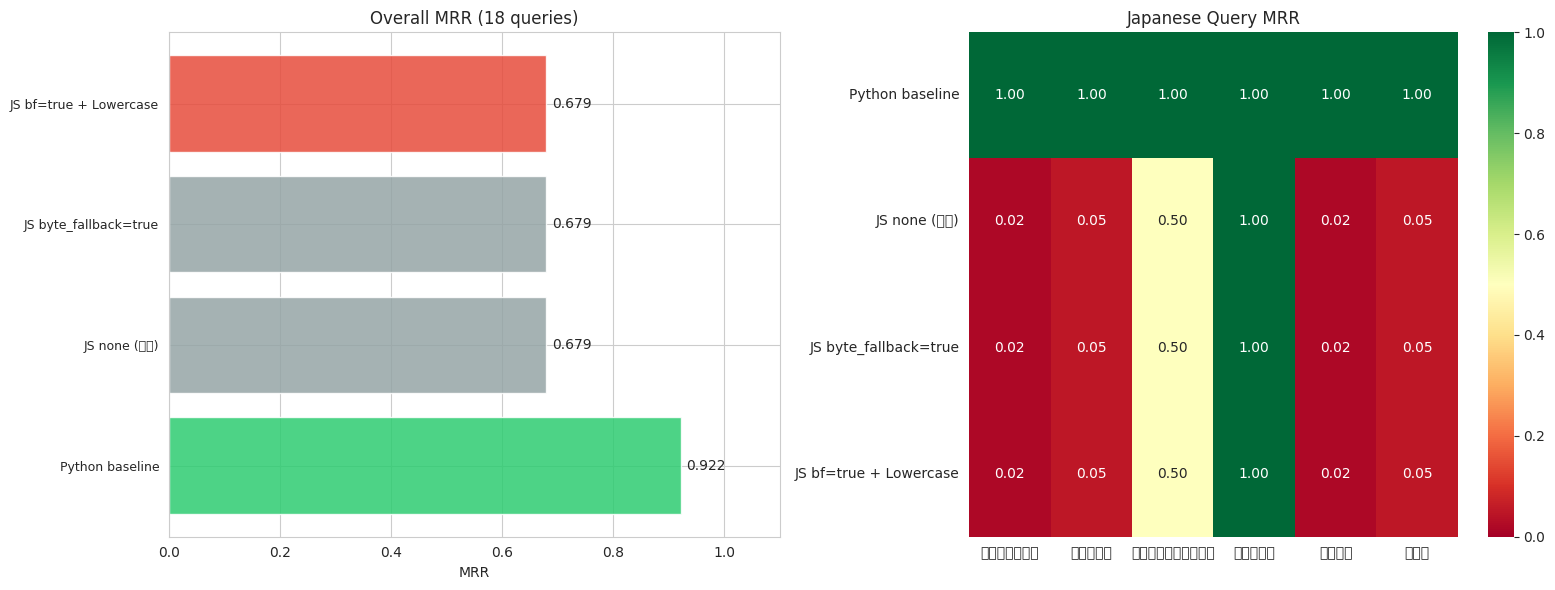

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# (1) 全体 MRR 比較
ax = axes[0]
approaches = results_df.index.tolist()
mrr_vals = results_df["MRR"].values
colors = ["#2ecc71" if "Python" in a else "#e74c3c" if "bf" in a else "#95a5a6" for a in approaches]

bars = ax.barh(range(len(approaches)), mrr_vals, color=colors, alpha=0.85)
ax.set_yticks(range(len(approaches)))
ax.set_yticklabels(approaches, fontsize=9)
for bar, val in zip(bars, mrr_vals):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
            f"{val:.3f}", va="center", fontsize=10)
ax.set_xlabel("MRR")
ax.set_title("Overall MRR (18 queries)")
ax.set_xlim(0, 1.1)

# (2) 日本語クエリ MRR ヒートマップ
ax = axes[1]
ja_mrr_matrix = []
strategy_names = []

py_res = evaluate_text_search(py_text_emb[12:], js_image_emb, ja_queries, py_categories)
ja_mrr_matrix.append(py_res["per_query_mrr"])
strategy_names.append("Python baseline")

for name, emb in strategies.items():
    res = evaluate_text_search(emb[12:], js_image_emb, ja_queries, py_categories)
    ja_mrr_matrix.append(res["per_query_mrr"])
    strategy_names.append(name)

sns.heatmap(
    np.array(ja_mrr_matrix),
    xticklabels=JA_QUERIES,
    yticklabels=strategy_names,
    annot=True, fmt=".2f", cmap="RdYlGn",
    vmin=0, vmax=1.0, ax=ax
)
ax.set_title("Japanese Query MRR")

plt.tight_layout()
plt.savefig(str(DATA_DIR / "40_byte_fallback_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()

## 8. 結果の保存

In [19]:
# 結果保存
results_40 = {
    "cosine_similarity": cos_df.to_dict(orient="index"),
    "overall_mrr": results_df["MRR"].to_dict(),
    "per_query_mrr": {},
}

for name, res in all_eval.items():
    results_40["per_query_mrr"][name] = {
        q["query"]: float(res["per_query_mrr"][i])
        for i, q in enumerate(test_queries)
    }

with open(DATA_DIR / "40_byte_fallback_results.json", "w") as f:
    json.dump(results_40, f, indent=2, ensure_ascii=False, default=float)

print("結果を保存: data/40_byte_fallback_results.json")

結果を保存: data/40_byte_fallback_results.json


## サマリー

### 実験結果

`tokenizer.json` の `byte_fallback` を `true` に変更しても **全く効果なし**。
トークン列、cosine similarity、MRR いずれも変化しなかった。

| 戦略 | JA cosine sim | JA MRR | EN MRR |
|------|--------------|--------|--------|
| JS none (現状) | 0.656 | 0.273 | 0.883 |
| JS byte_fallback=true | 0.656 | 0.273 | 0.883 |
| JS bf=true + Lowercase | 0.656 | 0.273 | 0.883 |
| Python baseline | 1.000 | 1.000 | 0.883 |

### 原因

**Transformers.js の Unigram tokenizer は `byte_fallback` を実装していない。**

- BPE tokenizer: byte_fallback 実装あり（UTF-8 バイトトークンへの分解に対応）
- **Unigram tokenizer: byte_fallback 未実装**（設定を `true` にしても完全に無視される）
- SigLIP は Unigram tokenizer を使用するため、byte_fallback が機能しない

### 処理の流れ

```
テキスト → [Normalizer] → [Unigram Tokenizer] → トークンID列 → [Text Encoder NN] → エンベディング
                              ↑ ここが問題
                              未知文字 → <unk> に変換（byte_fallback が効かない）
```

Python の SentencePiece C++ ライブラリは byte_fallback を内蔵しているが、
Transformers.js の JS 再実装では Unigram の byte_fallback が省略されている。

### Transformers.js ソースコード上の証拠

`tokenizers.js` の `Unigram.populateNodes()`:
- 未知文字に対して `lattice.insert(beginPos, mblen, this.unk_score, this.unk_token_id)` のみ
- バイトトークンへの分解ロジックなし

`BPE.encode()` との対比:
- BPE には `if (this.byte_fallback)` ブランチがあり、UTF-8 バイトトークンへの変換を実装
- Unigram にはこのブランチが存在しない

### 今後の対策候補

1. **Transformers.js の Unigram tokenizer に byte_fallback を自前実装**（最有望）
   - `populateNodes()` の未知文字処理にバイト分解を追加
   - 語彙に byte tokens (`<0x00>`〜`<0xFF>`) が存在するので変換先は存在する
2. **Python テキストエンコーダー API**: テキストエンベディングのみ Python で生成
3. **英語クエリへの翻訳**: LLM で日本語→英語変換してから検索
4. **Transformers.js へのバグレポート/PR**: Unigram byte_fallback 対応を提案